<a href="https://colab.research.google.com/github/akriti404/Deep-Learning-Lab/blob/main/lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.15MB/s]


Training VAE for 5 epochs...
Epoch 1/5 Complete
Epoch 2/5 Complete
Epoch 3/5 Complete
Epoch 4/5 Complete
Epoch 5/5 Complete


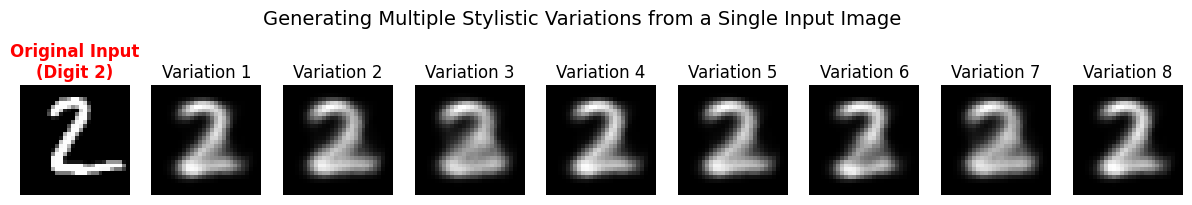

In [1]:
import torch

import torch.nn as nn

import torch.optim as optim

import torchvision

import torchvision.transforms as transforms

import matplotlib.pyplot as plt



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



class SimpleVAE(nn.Module):

    def __init__(self, latent_dim=2):

        super(SimpleVAE, self).__init__()

        # Encoder

        self.fc1 = nn.Linear(28 * 28, 256)

        self.fc_mu = nn.Linear(256, latent_dim)

        self.fc_logvar = nn.Linear(256, latent_dim)



        # Decoder

        self.fc3 = nn.Linear(latent_dim, 256)

        self.fc4 = nn.Linear(256, 28 * 28)



    def encode(self, x):

        h = torch.relu(self.fc1(x))

        return self.fc_mu(h), self.fc_logvar(h)



    def reparameterize(self, mu, logvar, scale=1.5):

        # Scale controls how distinct the generated variations will be

        std = torch.exp(0.5 * logvar) * scale

        eps = torch.randn_like(std)

        return mu + eps * std



    def decode(self, z):

        h = torch.relu(self.fc3(z))

        return torch.sigmoid(self.fc4(h))



    def forward(self, x):

        mu, logvar = self.encode(x.view(-1, 28 * 28))

        z = self.reparameterize(mu, logvar)

        return self.decode(z), mu, logvar



# Loss Function

def loss_function(recon_x, x, mu, logvar):

    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 28 * 28), reduction='sum')

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD



# 5 Epochs



transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)



model = SimpleVAE(latent_dim=2).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)



print("Training VAE for 5 epochs...")

model.train()

for epoch in range(5):

    for batch_idx, (data, _) in enumerate(train_loader):

        data = data.to(device)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss = loss_function(recon_batch, data, mu, logvar)

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/5 Complete")



# GENERATE MULTIPLE VARIATIONS FROM 1 DIGIT

model.eval()



# Pick 1 sample image from the dataset (e.g., a "2")

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

input_image, label = test_dataset[1]  # Index 1 is for the image '2'



input_tensor = input_image.unsqueeze(0).to(device) # Shape: [1, 1, 28, 28]



with torch.no_grad():

    # Encode the single input image

    mu, logvar = model.encode(input_tensor.view(-1, 28 * 28))



    # Sample 8 different latent vectors around this image's distribution

    num_variations = 8

    mu_repeat = mu.repeat(num_variations, 1)

    logvar_repeat = logvar.repeat(num_variations, 1)



    # Sample z points using the reparameterization trick

    z_samples = model.reparameterize(mu_repeat, logvar_repeat, scale=2.0)



    # Decode the 8 latent vectors into 8 new generated images

    generated_images = model.decode(z_samples).view(-1, 28, 28).cpu().numpy()



#visualization

fig, axes = plt.subplots(1, num_variations + 1, figsize=(15, 2))



# original input image

axes[0].imshow(input_image.squeeze().numpy(), cmap='gray')

axes[0].set_title(r"Original Input" + f"\n(Digit {label})", color='red', fontweight='bold')

axes[0].axis('off')



# Display for the 8 generated variations of that exact digit

for i in range(num_variations):

    axes[i + 1].imshow(generated_images[i], cmap='gray')

    axes[i + 1].set_title(f"Variation {i+1}")

    axes[i + 1].axis('off')



plt.suptitle(r"Generating Multiple Stylistic Variations from a Single Input Image", fontsize=14, y=1.15)

plt.show()

Training ConvVAE for 5 epochs...
Epoch 1/5 Complete - Avg Loss: 174.69
Epoch 2/5 Complete - Avg Loss: 120.48
Epoch 3/5 Complete - Avg Loss: 114.73
Epoch 4/5 Complete - Avg Loss: 111.76
Epoch 5/5 Complete - Avg Loss: 109.78


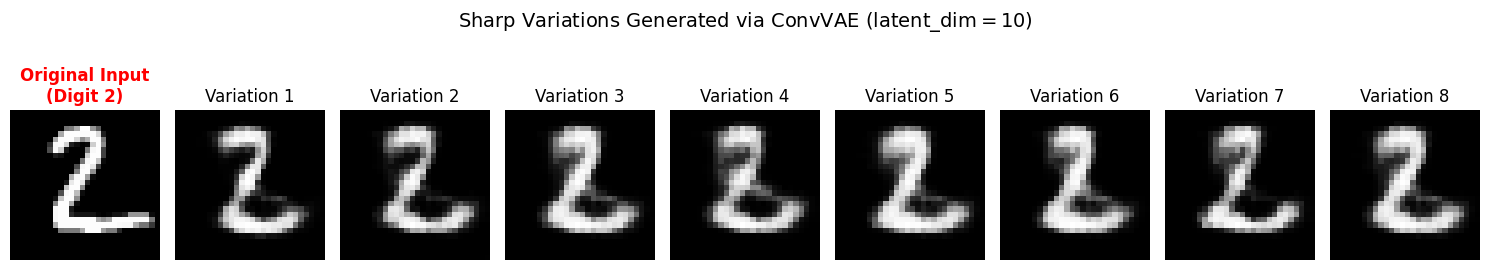

In [2]:
import torch

import torch.nn as nn

import torch.optim as optim

import torchvision

import torchvision.transforms as transforms

import matplotlib.pyplot as plt



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



class ConvVAE(nn.Module):

    def __init__(self, latent_dim=10):

        super(ConvVAE, self).__init__()



        # Input: [B, 1, 28, 28]

        self.encoder_conv = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # -> [B, 32, 14, 14]

            nn.BatchNorm2d(32),

            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> [B, 64, 7, 7]

            nn.BatchNorm2d(64),

            nn.LeakyReLU(0.2)

        )



        # Latent projections

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)

        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)



        self.decoder_fc = nn.Linear(latent_dim, 64 * 7 * 7)



        # Decoder: Transposed convolutions upscale latent features back to 28x28

        self.decoder_conv = nn.Sequential(

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> [B, 32, 14, 14]

            nn.BatchNorm2d(32),

            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> [B, 1, 28, 28]

            nn.Sigmoid()  # Outputs crisp normalized pixels [0, 1]

        )



    def encode(self, x):

        h = self.encoder_conv(x)

        h_flat = h.view(h.size(0), -1)

        return self.fc_mu(h_flat), self.fc_logvar(h_flat)



    def reparameterize(self, mu, logvar, scale=1.5):

        std = torch.exp(0.5 * logvar) * scale

        eps = torch.randn_like(std)

        return mu + eps * std



    def decode(self, z):

        h = self.decoder_fc(z)

        h_reshaped = h.view(-1, 64, 7, 7)

        return self.decoder_conv(h_reshaped)



    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        return self.decode(z), mu, logvar



# Loss Function with beta weighting for controlling variation diversity

def loss_function(recon_x, x, mu, logvar, beta=0.5):

    # Binary Cross Entropy for sharp pixel matching

    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL Divergence for latent regularization

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + (beta * KLD)



# TRAIN ConvVAE for 5 Epochs



transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)



model = ConvVAE(latent_dim=10).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)



print("Training ConvVAE for 5 epochs...")

model.train()

for epoch in range(5):

    total_loss = 0

    for batch_idx, (data, _) in enumerate(train_loader):

        data = data.to(device)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss = loss_function(recon_batch, data, mu, logvar, beta=0.5)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/5 Complete - Avg Loss: {total_loss / len(train_loader.dataset):.2f}")



model.eval()



# Select 1 sample image from the test set (e.g., digit '2')

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

input_image, label = test_dataset[1]  # Index 1 is typically a '2'



input_tensor = input_image.unsqueeze(0).to(device) # Shape: [1, 1, 28, 28]



with torch.no_grad():

    # Encode the single input image into 10D latent distribution

    mu, logvar = model.encode(input_tensor)



    # Sample 8 different latent vectors around this image's distribution

    num_variations = 8

    mu_repeat = mu.repeat(num_variations, 1)

    logvar_repeat = logvar.repeat(num_variations, 1)



    # Sample z points using scale=2.5

    z_samples = model.reparameterize(mu_repeat, logvar_repeat, scale=2.5)



    # Decode the 8 latent vectors into sharp generated images

    generated_images = model.decode(z_samples).squeeze(1).cpu().numpy()



#Visualization

fig, axes = plt.subplots(1, num_variations + 1, figsize=(15, 2.5))



# Display original input image

axes[0].imshow(input_image.squeeze().numpy(), cmap='gray')

axes[0].set_title(r"Original Input" + f"\n(Digit {label})", color='red', fontweight='bold')

axes[0].axis('off')



# Display the generated 8 variations

for i in range(num_variations):

    axes[i + 1].imshow(generated_images[i], cmap='gray')

    axes[i + 1].set_title(f"Variation {i+1}")

    axes[i + 1].axis('off')



plt.suptitle(r"Sharp Variations Generated via ConvVAE ($\text{latent\_dim}=10$)", fontsize=14, y=1.12)

plt.tight_layout()

plt.show()